<a href="https://colab.research.google.com/github/acaicomdados/analise-reservatorios-federais/blob/main/An%C3%A1lise%20feito%20nos%20encontros/An%C3%A1lise%20s%C3%A9rie%20hist%C3%B3rica/Bacia%20Tocantins/An%C3%A1lise_da_bacia_Tocantins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisnado o comportamento de outras usinas da bacia de tocantins

Hoje irá ser analisado outras usinas da bacia de Tocantins além da usina de Tucuruí da qual foi analisada no último encontro, e compara se o comportamentos de outras da mesma bacia são parecidos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/acaicomdados/analise-reservatorios-federais/main/Datasets/S%C3%A9rie%20hist%C3%B3rica/Tocantins/serie_historica_tocantins.csv'
bacia_tocantins = pd.read_csv(url)
bacia_tocantins.head()

,Unnamed: 0,data,id_reservatorio,nome_reservatorio,afluencia,bacia,rio,estado_sigla,ano,mes
0,1122646,2000-01-01,19128,SERRA DA MESA,1570.00,TOCANTINS,TOCANTINS,GO,2000,1
1,1122647,2000-01-02,19128,SERRA DA MESA,2070.94,TOCANTINS,TOCANTINS,GO,2000,1
2,1122648,2000-01-03,19128,SERRA DA MESA,2927.00,TOCANTINS,TOCANTINS,GO,2000,1
3,1122649,2000-01-06,19128,SERRA DA MESA,2379.00,TOCANTINS,TOCANTINS,GO,2000,1
4,1122650,2000-01-09,19128,SERRA DA MESA,3050.00,TOCANTINS,TOCANTINS,GO,2000,1


In [3]:
bacia_tocantins.drop(['Unnamed: 0','id_reservatorio','rio','estado_sigla'],axis=1,inplace=True)
bacia_tocantins.head()

,data,nome_reservatorio,afluencia,bacia,ano,mes
0,2000-01-01,SERRA DA MESA,1570.00,TOCANTINS,2000,1
1,2000-01-02,SERRA DA MESA,2070.94,TOCANTINS,2000,1
2,2000-01-03,SERRA DA MESA,2927.00,TOCANTINS,2000,1
3,2000-01-06,SERRA DA MESA,2379.00,TOCANTINS,2000,1
4,2000-01-09,SERRA DA MESA,3050.00,TOCANTINS,2000,1


In [4]:
bacia_tocantins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54320 entries, 0 to 54319
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data               54320 non-null  object 
 1   nome_reservatorio  54320 non-null  object 
 2   afluencia          54291 non-null  float64
 3   bacia              54320 non-null  object 
 4   ano                54320 non-null  int64  
 5   mes                54320 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 2.5+ MB


In [5]:
bacia_tocantins['data'] = pd.to_datetime(bacia_tocantins['data'],format='%Y-%m-%d')
bacia_tocantins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54320 entries, 0 to 54319
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data               54320 non-null  datetime64[ns]
 1   nome_reservatorio  54320 non-null  object        
 2   afluencia          54291 non-null  float64       
 3   bacia              54320 non-null  object        
 4   ano                54320 non-null  int64         
 5   mes                54320 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 2.5+ MB


In [8]:
bacia_tocantins.sort_values(by='data',inplace=True)
bacia_tocantins.head()

,data,nome_reservatorio,afluencia,bacia,ano,mes
0,2000-01-01,SERRA DA MESA,1570.00,TOCANTINS,2000,1
12076,2000-01-01,CANA BRAVA,813.51,TOCANTINS,2000,1
22132,2000-01-01,PEIXE ANGICAL,3754.54,TOCANTINS,2000,1
34265,2000-01-01,LAJEADO,6226.65,TOCANTINS,2000,1
38226,2000-01-01,ESTREITO,10673.17,TOCANTINS,2000,1


Text(0, 0.5, 'Afluencia (m3/s)')

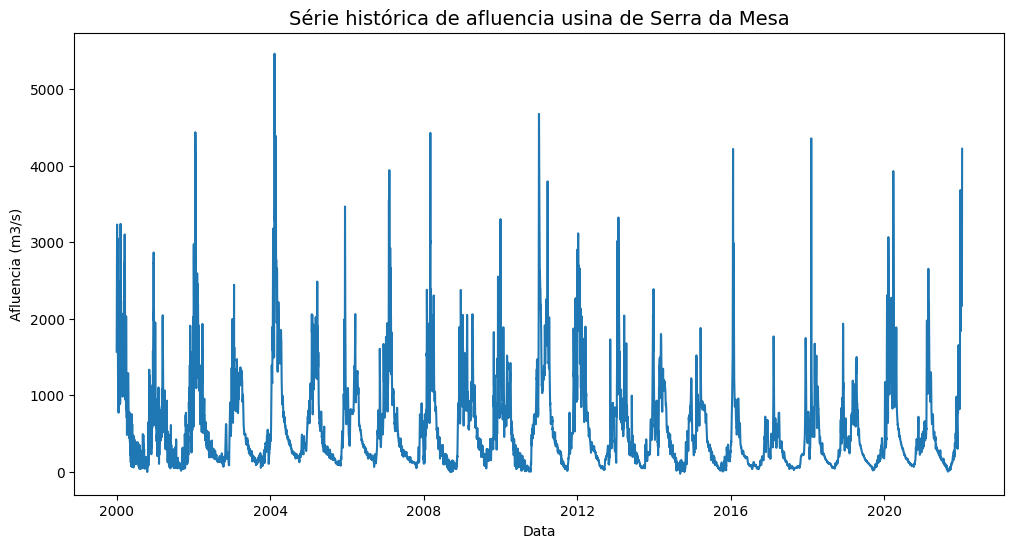

In [10]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina de Serra da Mesa',fontsize=14)
sns.lineplot(data=bacia_tocantins[bacia_tocantins['nome_reservatorio']=='SERRA DA MESA'],
             x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

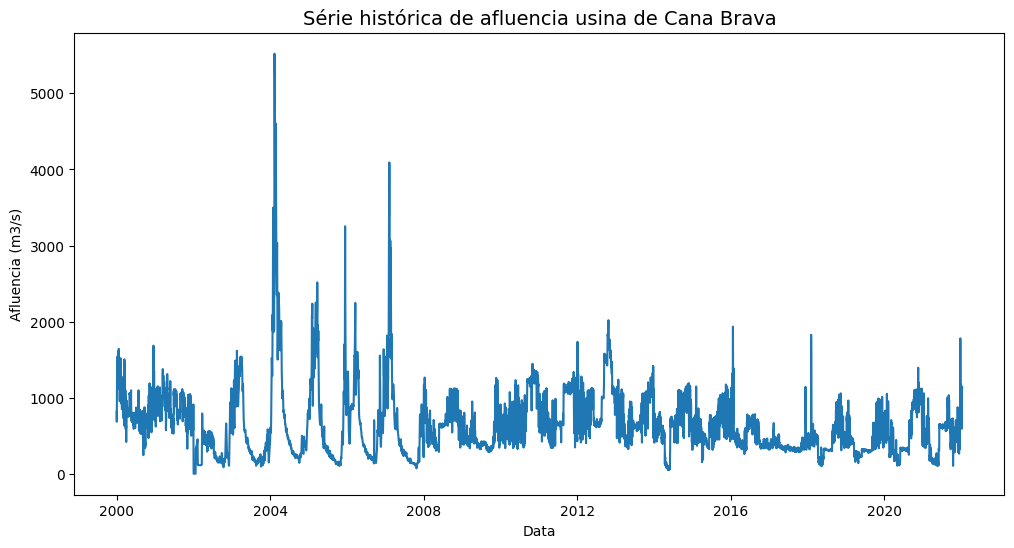

In [12]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina de Cana Brava',fontsize=14)
sns.lineplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='CANA BRAVA')&(bacia_tocantins['afluencia']<20000)],
             x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

Quanto a essa valor de 20 mil, verificar se  algo foi digitado incorretamento ou foi uma situação atipica

Essa usina tem um coportamento mais irregular comparada com outras até então desta mesma bacia

Text(0, 0.5, 'Afluencia (m3/s)')

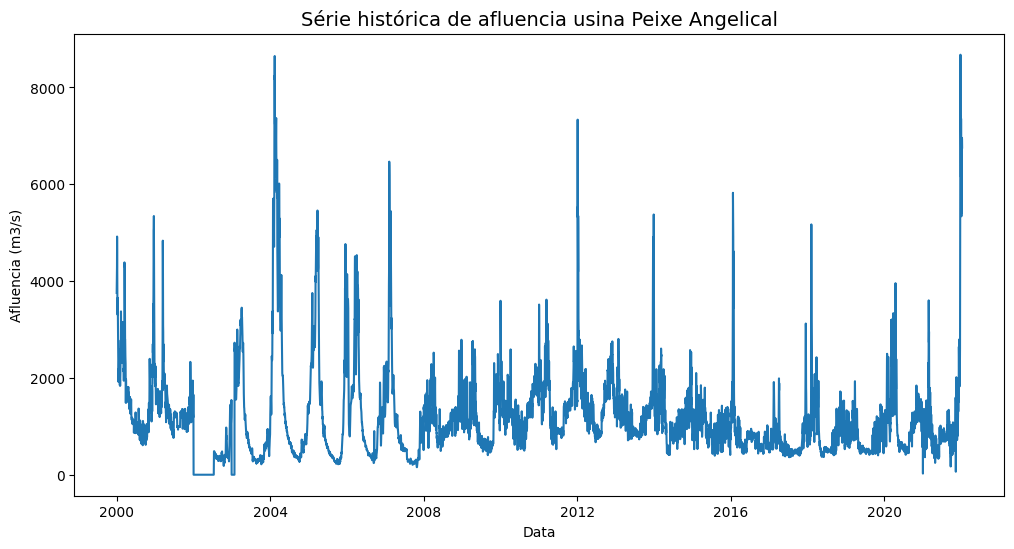

In [13]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina Peixe Angelical',fontsize=14)
sns.lineplot(data=bacia_tocantins[bacia_tocantins['nome_reservatorio']=='PEIXE ANGICAL'],
             x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

In [15]:
bacia_tocantins['afluencia'] = np.where(bacia_tocantins['afluencia']<0,bacia_tocantins['afluencia']*-1,bacia_tocantins['afluencia'])

Text(0, 0.5, 'Afluencia (m3/s)')

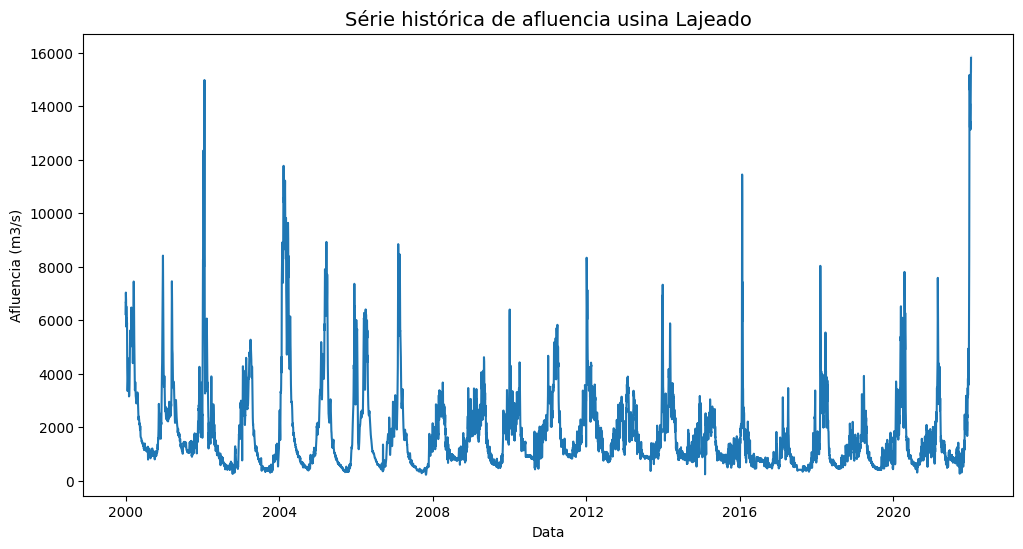

In [19]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina Lajeado',fontsize=14)
sns.lineplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='LAJEADO')&(bacia_tocantins['afluencia']<40000)],
             x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

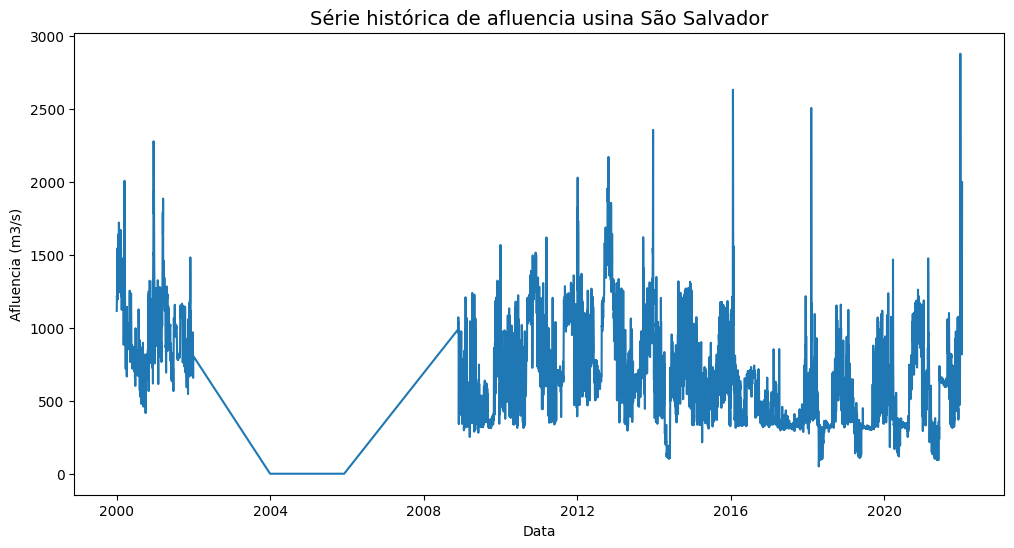

In [20]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina São Salvador',fontsize=14)
sns.lineplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='SAO SALVADOR')],
             x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

Sobre a usina sde são salvador deve ter occorido algo que não se teve coleta ou teve um não se tem registro de 2003 a 2007

Text(0, 0.5, 'Afluencia (m3/s)')

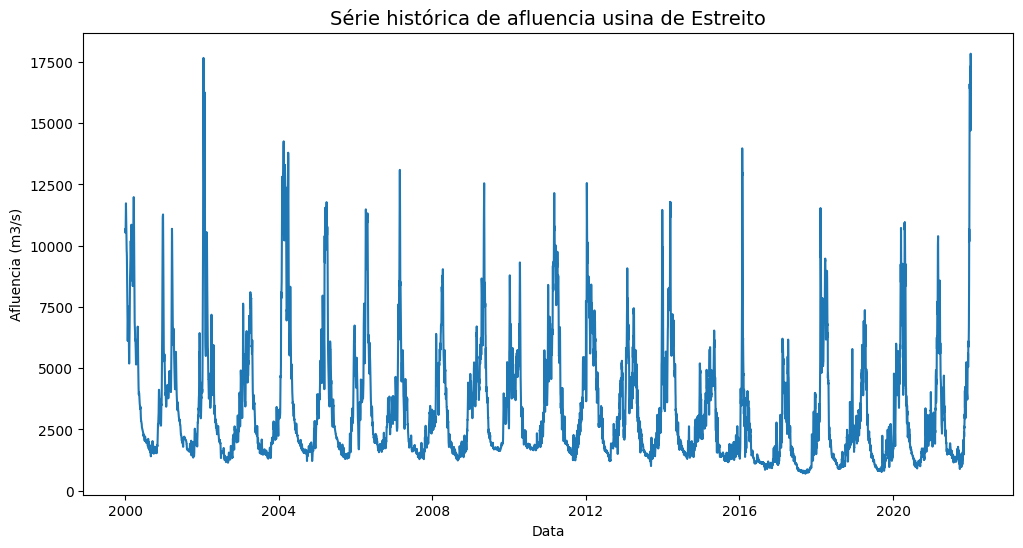

In [21]:
plt.figure(figsize=(12,6))
plt.title('Série histórica de afluencia usina de Estreito',fontsize=14)
sns.lineplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='ESTREITO')],
             x='data',y='afluencia')
plt.xlabel('Data')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

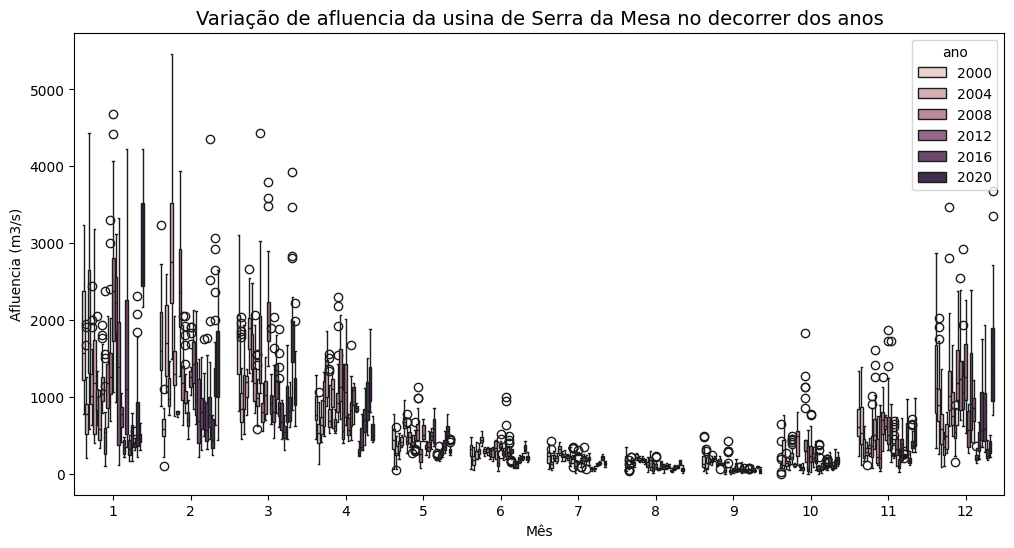

In [22]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de Serra da Mesa no decorrer dos anos',fontsize=14)
sns.boxplot(data=bacia_tocantins[bacia_tocantins['nome_reservatorio']=='SERRA DA MESA'],
            x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

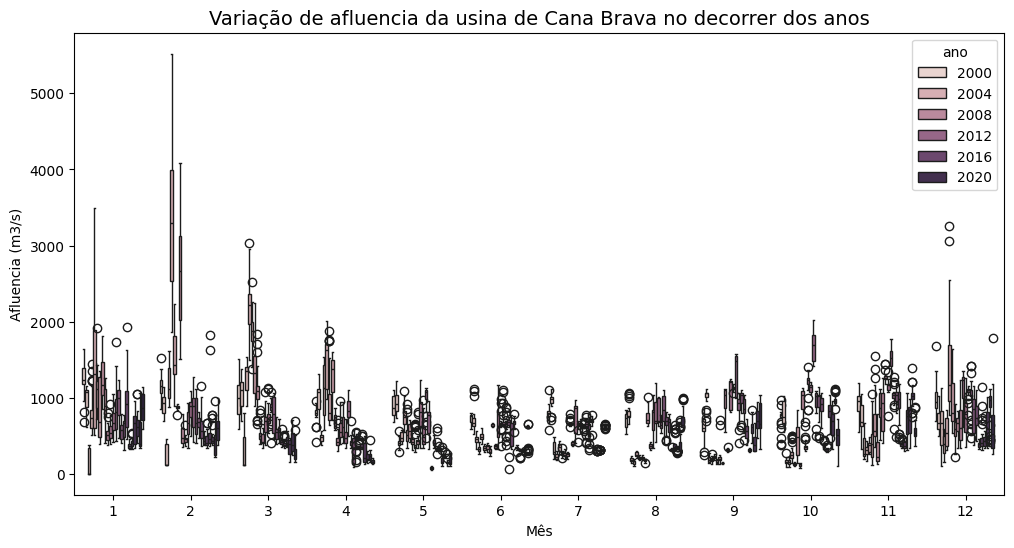

In [23]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de Cana Brava no decorrer dos anos',fontsize=14)
sns.boxplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='CANA BRAVA')&(bacia_tocantins['afluencia']<20000)],
            x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

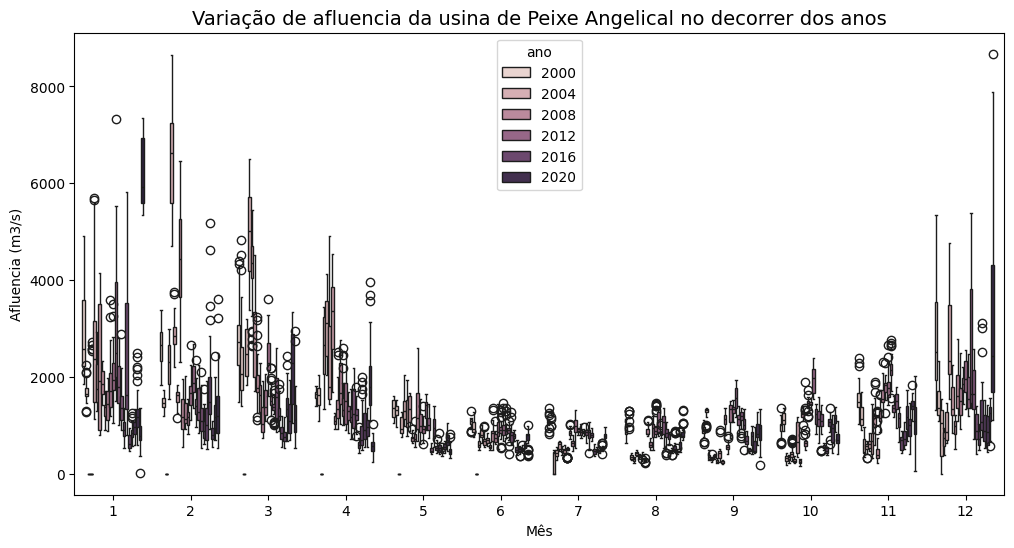

In [24]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de Peixe Angelical no decorrer dos anos',fontsize=14)
sns.boxplot(data=bacia_tocantins[bacia_tocantins['nome_reservatorio']=='PEIXE ANGICAL'],
            x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

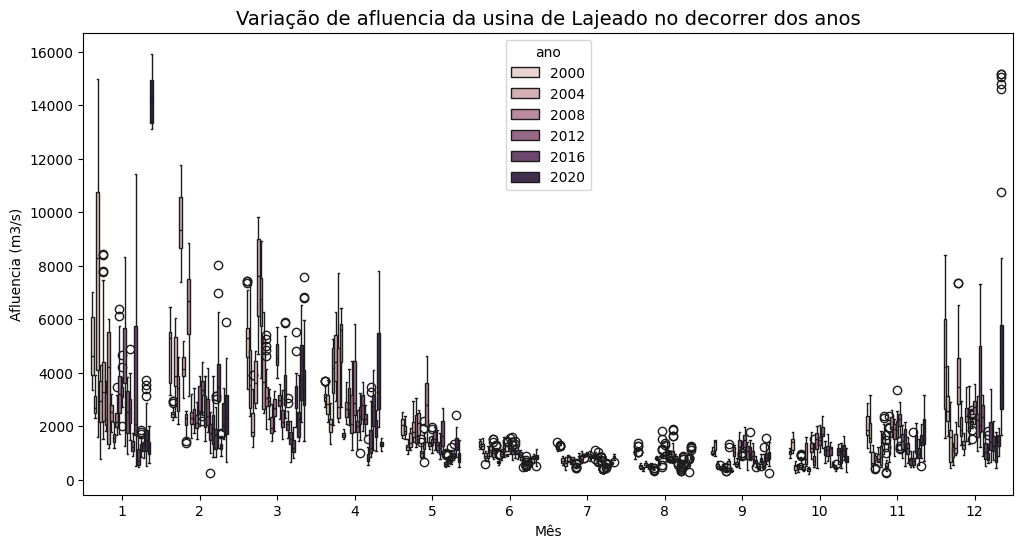

In [25]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de Lajeado no decorrer dos anos',fontsize=14)
sns.boxplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='LAJEADO')&(bacia_tocantins['afluencia']<40000)],
            x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

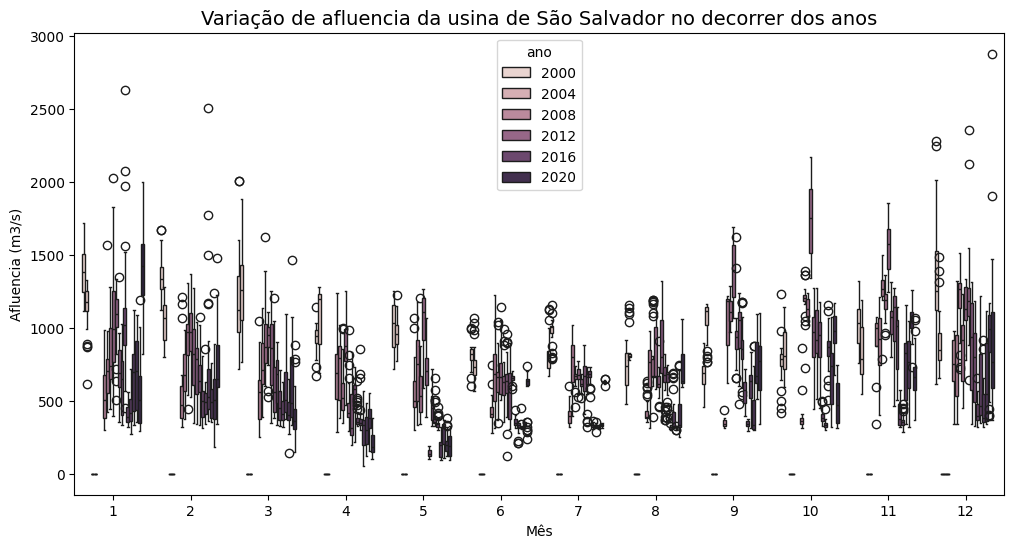

In [26]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de São Salvador no decorrer dos anos',fontsize=14)
sns.boxplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='SAO SALVADOR')],
            x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)')

Text(0, 0.5, 'Afluencia (m3/s)')

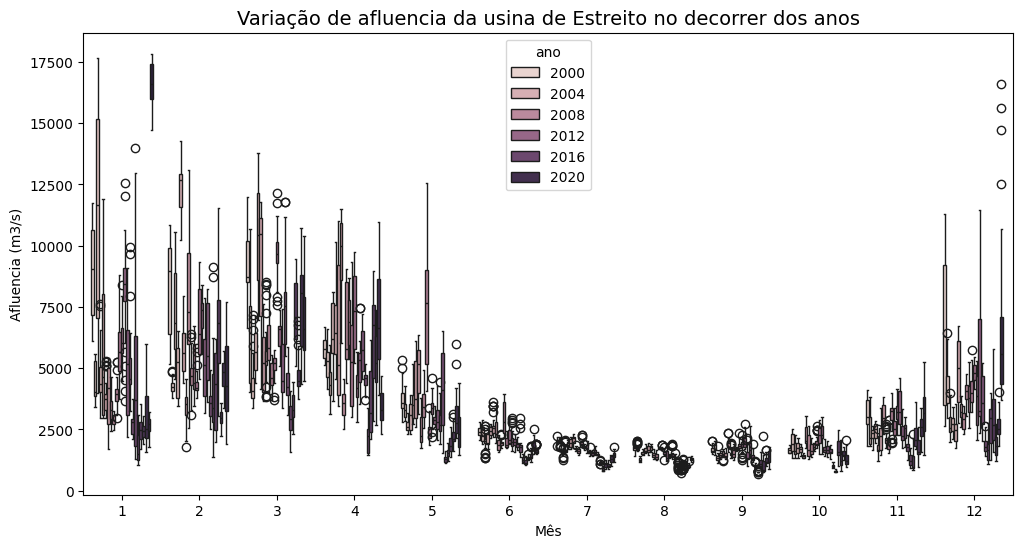

In [27]:
plt.figure(figsize=(12,6))
plt.title('Variação de afluencia da usina de Estreito no decorrer dos anos',fontsize=14)
sns.boxplot(data=bacia_tocantins[(bacia_tocantins['nome_reservatorio']=='ESTREITO')],
            x='mes',y='afluencia',hue='ano')
plt.xlabel('Mês')
plt.ylabel('Afluencia (m3/s)')

Pelos graficos acima de forma a perceber a tendência do compartamento da afluencia, podemos perceber que:

- Serra da Mesa, Peixe Angelical tem comportamentos muito parecidos e sua chei é no periodo de fevereiro e março, enquanto Estreito tem um comportamento mais parecido com Tucurui , com cheia de março e abril, principalmente.

- São Salvador e Cana Brava parece ter um comportmaneto difierente


Estreito deve ter um comprtamento parecido com Tucurui pois são os reservatório mais próximos (verificar)





## Para o próximo encontro

- Verificar se existem realmente essas relações apresentadas
- Verificar se os dados foram coletado corretamente jáque há reservatório com valores atipicos
- Analisar melhor também só a tendencia e verificar melhor a sazonalidade